# 🔬 Active Learning + Conformal Prediction on CIFAR-10

## Research Question
**Does Conformal Prediction help Active Learning achieve better accuracy with less data?**

## 8 Strategies Compared
1. **Random** - Baseline
2. **Entropy** - High entropy = uncertain
3. **Least Confidence** - Low max probability
4. **Margin** - Small margin between top-2
5. **CP Size** - Large prediction set (original)
6. **CP V-shaped** - NEW: Prioritizes set_size=0 AND large sets
7. **Combined** - Entropy + CP Size
8. **Combined V-shaped** - NEW: Entropy + V-shaped CP

## 1. Setup

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
import numpy as np
import matplotlib.pyplot as plt
import copy, random

print(f"CUDA: {torch.cuda.is_available()}")
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

CUDA: True


## 2. Configuration

In [2]:
SEED = 42
TOTAL_TRAIN_SAMPLES = 50000
INITIAL_LABELED = 5000
CALIBRATION_SIZE = 5000
BUDGET_PER_ROUND = 2000
NUM_ROUNDS = 21
EPOCHS_PER_ROUND = 10
BATCH_SIZE = 128
LR, MOMENTUM, WD = 0.01, 0.9, 5e-4
CP_ALPHA = 0.1
TARGET_ACCURACIES = [85, 88, 90, 92, 94, 95]

# All 8 strategies
STRATEGIES = ["random", "entropy", "least_confidence", "margin", 
              "cp_size", "cp_v_shaped", "combined", "combined_v_shaped"]

CIFAR10_MEAN, CIFAR10_STD = (0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)

def set_seed(seed=SEED):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)
print(f"Device: {DEVICE}")

Device: cuda


## 3. Model & Data

In [3]:
transform_train = transforms.Compose([transforms.RandomCrop(32, padding=4), transforms.RandomHorizontalFlip(),
    transforms.ToTensor(), transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD)])
transform_test = transforms.Compose([transforms.ToTensor(), transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD)])

def get_model():
    model = models.resnet18(weights='IMAGENET1K_V1')
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()
    model.fc = nn.Linear(model.fc.in_features, 10)
    return model

train_set = datasets.CIFAR10(root="./data", train=True, download=True, transform=transform_train)
test_set = datasets.CIFAR10(root="./data", train=False, download=True, transform=transform_test)
print(f"Train: {len(train_set)}, Test: {len(test_set)}")

/venv/main/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Train: 50000, Test: 10000


## 4. Acquisition Strategies

In [4]:
def get_probs(model, loader, device=DEVICE):
    model.eval()
    probs, labels = [], []
    with torch.no_grad():
        for x, y in loader:
            probs.append(F.softmax(model(x.to(device)), dim=1).cpu())
            labels.append(y)
    return torch.cat(probs), torch.cat(labels)

def random_sampling(probs, budget, **kw):
    return torch.topk(torch.rand(len(probs)), budget)[1]

def entropy_sampling(probs, budget, **kw):
    entropy = -(probs * torch.log(probs + 1e-9)).sum(dim=1)
    return torch.topk(entropy, budget)[1]

def least_confidence_sampling(probs, budget, **kw):
    return torch.topk(1 - probs.max(dim=1)[0], budget)[1]

def margin_sampling(probs, budget, **kw):
    sorted_p, _ = torch.sort(probs, dim=1, descending=True)
    return torch.topk(-(sorted_p[:, 0] - sorted_p[:, 1]), budget)[1]

def cp_set_size_sampling(probs, budget, qhat, **kw):
    """Original: select largest set sizes"""
    set_sizes = (probs >= (1 - qhat)).sum(dim=1).float()
    return torch.topk(set_sizes, budget)[1]

def cp_v_shaped_sampling(probs, budget, qhat, **kw):
    """V-shaped: prioritize set_size=0 (overconfident errors) AND large sets"""
    num_classes = probs.shape[1]
    set_sizes = (probs >= (1 - qhat)).sum(dim=1).float()
    # V-shaped: 0 -> highest, 1 -> lowest, >1 -> increasing
    score = torch.where(set_sizes == 0, torch.tensor(num_classes + 1.0),
                torch.where(set_sizes == 1, torch.tensor(0.0), set_sizes))
    return torch.topk(score, budget)[1]

def combined_sampling(probs, budget, qhat, **kw):
    """Original Combined: Entropy + CP size"""
    num_classes = probs.shape[1]
    entropy_norm = -(probs * torch.log(probs + 1e-9)).sum(dim=1) / np.log(num_classes)
    set_sizes_norm = (probs >= (1 - qhat)).sum(dim=1).float() / num_classes
    return torch.topk(0.5 * entropy_norm + 0.5 * set_sizes_norm, budget)[1]

def combined_v_shaped_sampling(probs, budget, qhat, **kw):
    """V-shaped Combined: Entropy + V-shaped CP"""
    num_classes = probs.shape[1]
    entropy_norm = -(probs * torch.log(probs + 1e-9)).sum(dim=1) / np.log(num_classes)
    set_sizes = (probs >= (1 - qhat)).sum(dim=1).float()
    cp_score = torch.where(set_sizes == 0, torch.tensor(1.0),
                   torch.where(set_sizes == 1, torch.tensor(0.0), set_sizes / num_classes))
    return torch.topk(0.5 * entropy_norm + 0.5 * cp_score, budget)[1]

ACQ_FN = {"random": random_sampling, "entropy": entropy_sampling, "least_confidence": least_confidence_sampling,
          "margin": margin_sampling, "cp_size": cp_set_size_sampling, "cp_v_shaped": cp_v_shaped_sampling,
          "combined": combined_sampling, "combined_v_shaped": combined_v_shaped_sampling}
print(f"Defined {len(ACQ_FN)} acquisition functions!")

Defined 8 acquisition functions!


## 5. CP & Training Utilities

In [5]:
def compute_qhat(model, loader, alpha=CP_ALPHA, device=DEVICE):
    probs, labels = get_probs(model, loader, device)
    scores = 1 - probs[torch.arange(len(labels)), labels]
    k = int(np.ceil((len(labels) + 1) * (1 - alpha)))
    return torch.sort(scores)[0][min(k-1, len(labels)-1)].item()

def eval_acc(model, loader, device=DEVICE):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for x, y in loader:
            correct += (model(x.to(device)).argmax(1) == y.to(device)).sum().item()
            total += len(y)
    return 100. * correct / total

def train_round(model, loader, epochs=EPOCHS_PER_ROUND, device=DEVICE):
    model.train()
    opt = optim.SGD(model.parameters(), lr=LR, momentum=MOMENTUM, weight_decay=WD)
    sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    for _ in range(epochs):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            opt.zero_grad(); F.cross_entropy(model(x), y).backward(); opt.step()
        sched.step()

print("Utilities defined!")

Utilities defined!


## 6. Run Experiments

In [6]:
def run_experiment(strategy, train_set, test_set, init_idx, calib_idx, pool_idx, base_model, device=DEVICE):
    print(f"\n{'='*70}\n{strategy.upper()}\n{'='*70}")
    model = copy.deepcopy(base_model).to(device)
    labeled_idx, pool = list(init_idx), list(pool_idx)
    total_avail = len(init_idx) + len(pool_idx)
    
    calib_loader = DataLoader(Subset(train_set, calib_idx), batch_size=BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False)
    
    results = {'strategy': strategy, 'accuracies': [], 'labeled_sizes': [], 
               'cp_coverage': [], 'cp_avg_set_size': [], 'zero_sets': [], 'rounds': []}
    samples_trained = 0
    
    for r in range(NUM_ROUNDS + 1):
        acc = eval_acc(model, test_loader, device)
        qhat = compute_qhat(model, calib_loader, CP_ALPHA, device)
        test_probs, test_labels = get_probs(model, test_loader, device)
        pred_sets = test_probs >= (1 - qhat)
        coverage = pred_sets[torch.arange(len(test_labels)), test_labels].float().mean().item()
        avg_size = pred_sets.sum(dim=1).float().mean().item()
        zero_sets = (pred_sets.sum(dim=1) == 0).sum().item()
        
        results['accuracies'].append(acc)
        results['labeled_sizes'].append(samples_trained)
        results['cp_coverage'].append(coverage)
        results['cp_avg_set_size'].append(avg_size)
        results['zero_sets'].append(zero_sets)
        results['rounds'].append(r)
        
        pct = 100 * samples_trained / total_avail if samples_trained > 0 else 0
        print(f"R{r:2d}: Acc={acc:5.2f}% | Trained={samples_trained:5d} ({pct:4.1f}%) | Cov={coverage:.3f} | AvgSet={avg_size:.2f} | Zero={zero_sets}")
        
        if r == NUM_ROUNDS: break
        
        # Train
        train_round(model, DataLoader(Subset(train_set, labeled_idx), batch_size=BATCH_SIZE, shuffle=True), EPOCHS_PER_ROUND, device)
        samples_trained = len(labeled_idx)
        
        # Select new samples
        if r < NUM_ROUNDS - 1:
            qhat = compute_qhat(model, calib_loader, CP_ALPHA, device)
            pool_probs, _ = get_probs(model, DataLoader(Subset(train_set, pool), batch_size=BATCH_SIZE, shuffle=False), device)
            sel_idx = ACQ_FN[strategy](pool_probs, BUDGET_PER_ROUND, qhat=qhat)
            sel_global = [pool[i] for i in sel_idx.tolist()]
            labeled_idx.extend(sel_global)
            pool = [i for i in pool if i not in set(sel_global)]
    
    return results

print("Experiment function defined!")

Experiment function defined!


In [7]:
# RUN EXPERIMENTS
set_seed(SEED)
idx = np.random.permutation(len(train_set))
init_idx = idx[:INITIAL_LABELED].tolist()
calib_idx = idx[INITIAL_LABELED:INITIAL_LABELED + CALIBRATION_SIZE].tolist()
pool_idx = idx[INITIAL_LABELED + CALIBRATION_SIZE:].tolist()
print(f"Init: {len(init_idx)}, Calib: {len(calib_idx)}, Pool: {len(pool_idx)}")

base_model = get_model()
all_results = {s: run_experiment(s, train_set, test_set, init_idx, calib_idx, pool_idx, base_model, DEVICE) for s in STRATEGIES}
print("\n" + "="*70 + "\nDONE!\n" + "="*70)

Init: 5000, Calib: 5000, Pool: 40000

RANDOM
R 0: Acc=11.72% | Trained=    0 ( 0.0%) | Cov=0.928 | AvgSet=9.25 | Zero=0
R 1: Acc=80.44% | Trained= 5000 (11.1%) | Cov=0.893 | AvgSet=1.33 | Zero=0
R 2: Acc=84.62% | Trained= 7000 (15.6%) | Cov=0.901 | AvgSet=1.18 | Zero=0
R 3: Acc=86.61% | Trained= 9000 (20.0%) | Cov=0.904 | AvgSet=1.11 | Zero=0
R 4: Acc=87.72% | Trained=11000 (24.4%) | Cov=0.900 | AvgSet=1.05 | Zero=1
R 5: Acc=89.28% | Trained=13000 (28.9%) | Cov=0.900 | AvgSet=1.02 | Zero=37
R 6: Acc=89.57% | Trained=15000 (33.3%) | Cov=0.900 | AvgSet=1.01 | Zero=44
R 7: Acc=90.68% | Trained=17000 (37.8%) | Cov=0.900 | AvgSet=0.98 | Zero=151
R 8: Acc=91.14% | Trained=19000 (42.2%) | Cov=0.907 | AvgSet=0.99 | Zero=129
R 9: Acc=91.38% | Trained=21000 (46.7%) | Cov=0.904 | AvgSet=0.97 | Zero=271
R10: Acc=92.27% | Trained=23000 (51.1%) | Cov=0.911 | AvgSet=0.97 | Zero=265
R11: Acc=92.53% | Trained=25000 (55.6%) | Cov=0.908 | AvgSet=0.96 | Zero=381
R12: Acc=92.90% | Trained=27000 (60.0%) | C

## 7. Visualization

In [8]:
COLORS = {'random': '#808080', 'entropy': '#2E86AB', 'least_confidence': '#A23B72', 'margin': '#F18F01', 
          'cp_size': '#C73E1D', 'cp_v_shaped': '#8B0000', 'combined': '#3A7D44', 'combined_v_shaped': '#006400'}
LABELS = {'random': 'Random', 'entropy': 'Entropy', 'least_confidence': 'Least Conf', 'margin': 'Margin',
          'cp_size': 'CP Size', 'cp_v_shaped': 'CP V-shaped', 'combined': 'Combined', 'combined_v_shaped': 'Comb V-shaped'}

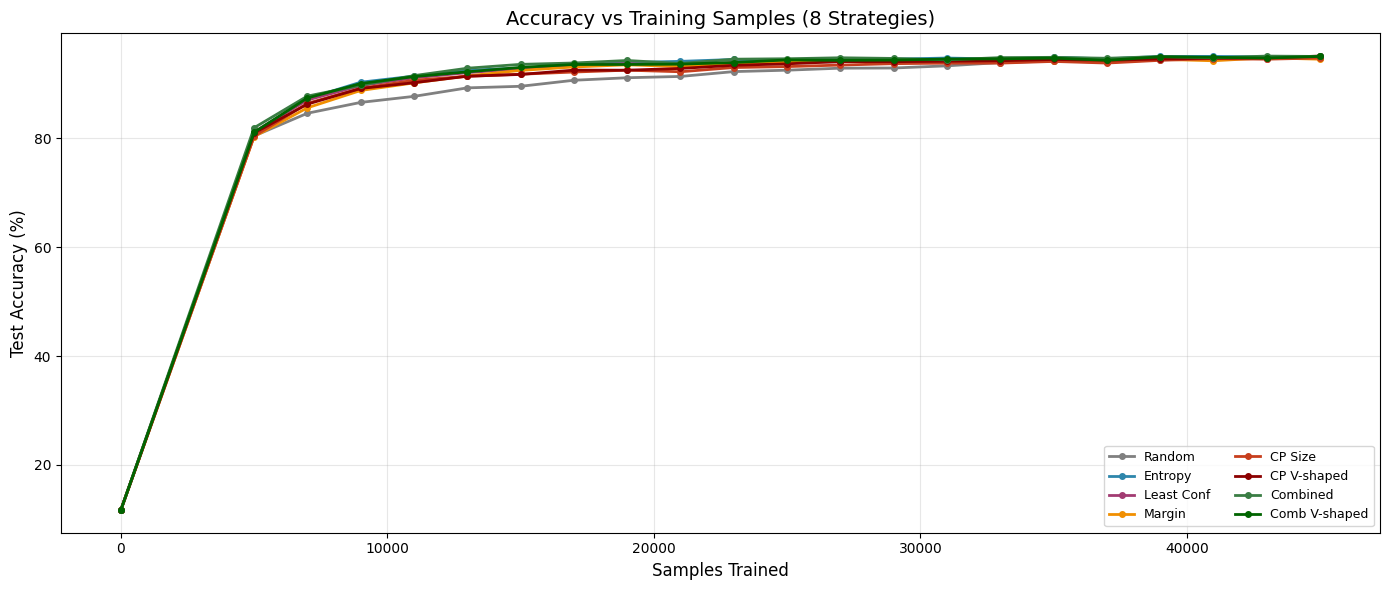

In [9]:
# Accuracy vs Samples
plt.figure(figsize=(14, 6))
for s, d in all_results.items():
    plt.plot(d['labeled_sizes'], d['accuracies'], label=LABELS[s], color=COLORS[s], marker='o', markersize=4, linewidth=2)
plt.xlabel('Samples Trained', fontsize=12); plt.ylabel('Test Accuracy (%)', fontsize=12)
plt.title('Accuracy vs Training Samples (8 Strategies)', fontsize=14)
plt.legend(fontsize=9, ncol=2); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

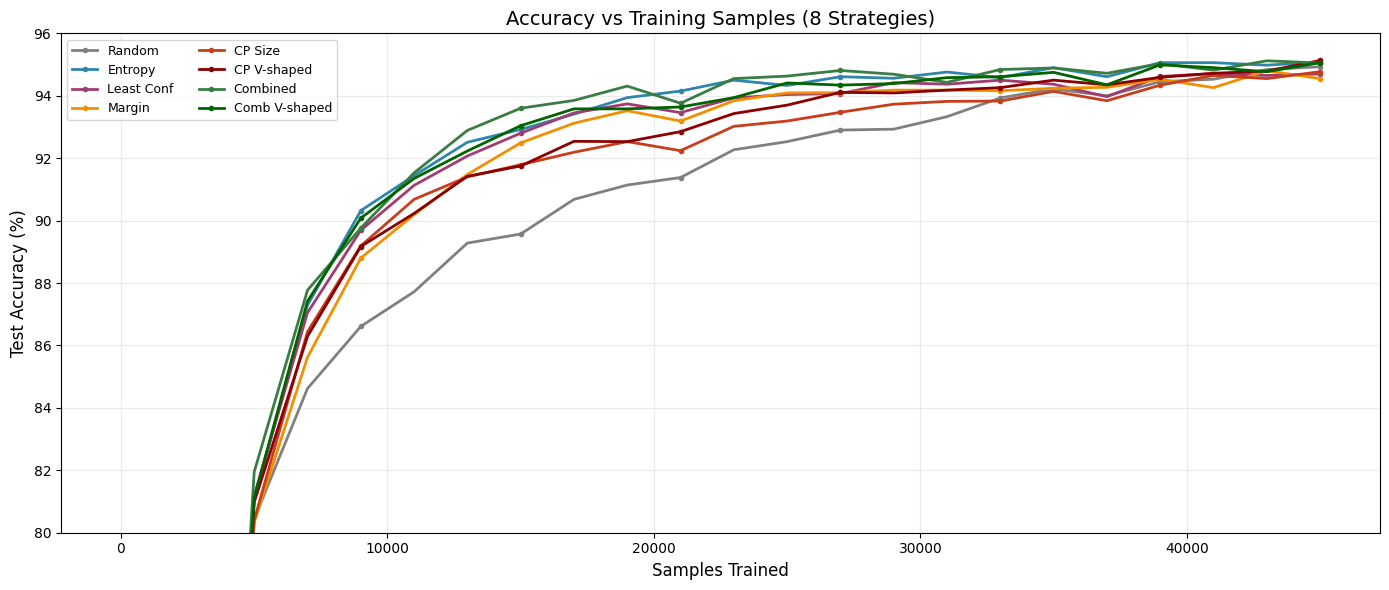

In [13]:
# Accuracy vs Samples
plt.figure(figsize=(14, 6))

for s, d in all_results.items():
    plt.plot(
        d['labeled_sizes'],
        d['accuracies'],
        label=LABELS[s],
        color=COLORS[s],
        linewidth=2,
        marker='o',
        markersize=3,
        markevery=3   # 👈 giãn marker hơn nữa
    )

plt.xlabel('Samples Trained', fontsize=12)
plt.ylabel('Test Accuracy (%)', fontsize=12)
plt.title('Accuracy vs Training Samples (8 Strategies)', fontsize=14)

plt.ylim(80, 96)     # 👈 giãn đúng range m cần
plt.legend(fontsize=9, ncol=2)
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()


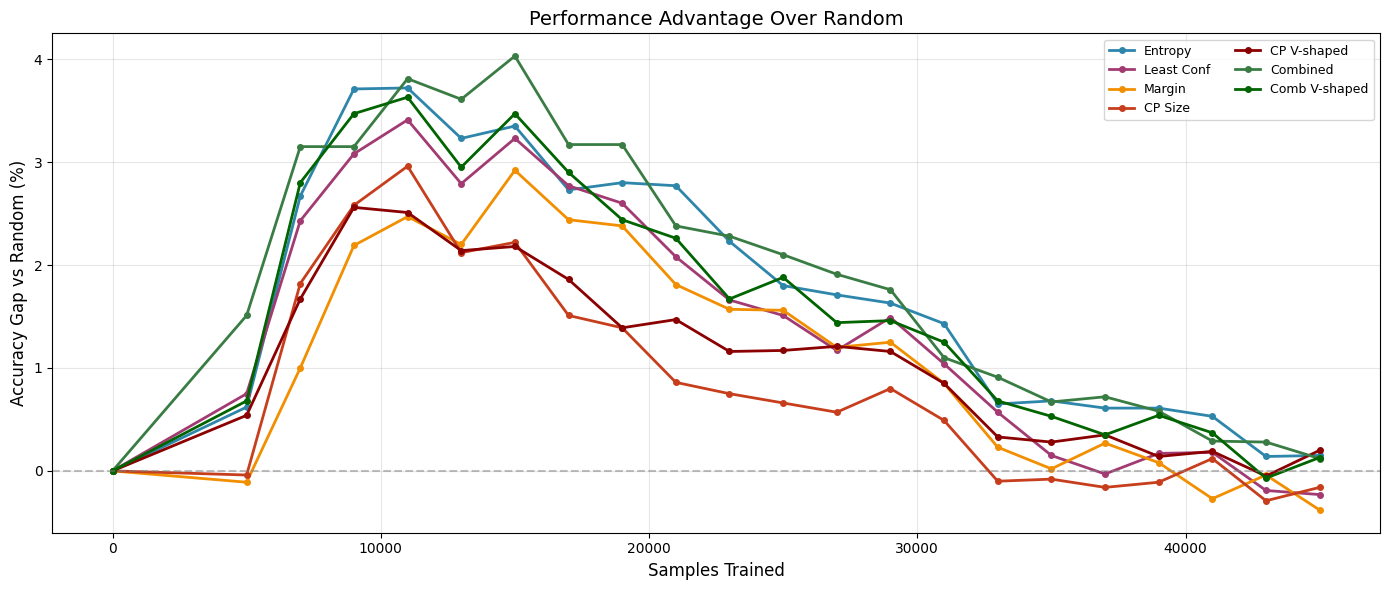

In [10]:
# Accuracy Gap vs Random
plt.figure(figsize=(14, 6))
baseline = all_results['random']['accuracies']
for s, d in all_results.items():
    if s == 'random': continue
    gap = [a - b for a, b in zip(d['accuracies'], baseline)]
    plt.plot(d['labeled_sizes'], gap, label=LABELS[s], color=COLORS[s], marker='o', markersize=4, linewidth=2)
plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.xlabel('Samples Trained', fontsize=12); plt.ylabel('Accuracy Gap vs Random (%)', fontsize=12)
plt.title('Performance Advantage Over Random', fontsize=14)
plt.legend(fontsize=9, ncol=2); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

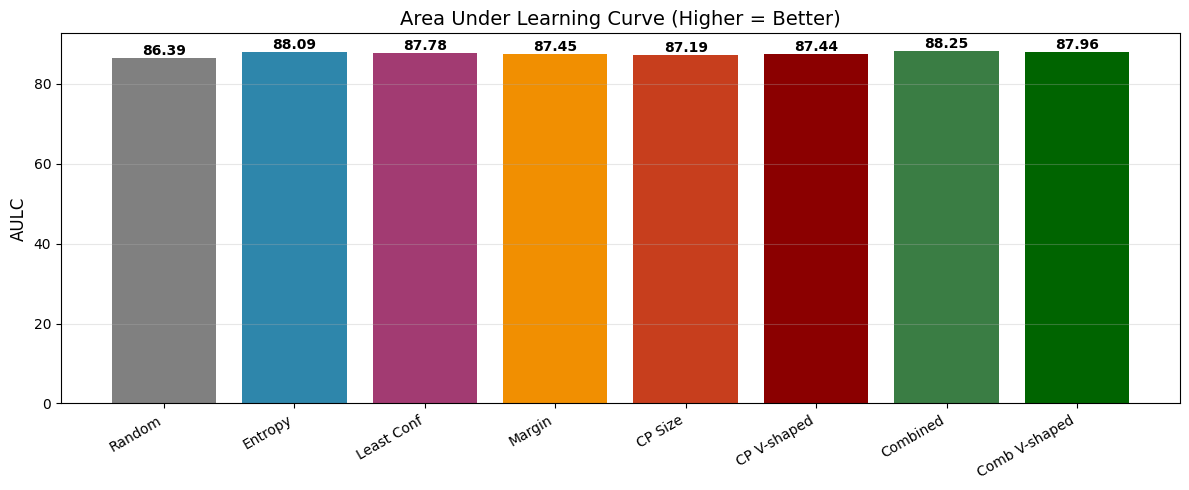

In [ ]:
# AULC
def aulc(res):
    total = TOTAL_TRAIN_SAMPLES - CALIBRATION_SIZE
    return np.trapezoid(res['accuracies'], [s/total for s in res['labeled_sizes']])

aulc_vals = {s: aulc(d) for s, d in all_results.items()}
plt.figure(figsize=(12, 5))
bars = plt.bar([LABELS[s] for s in aulc_vals], list(aulc_vals.values()), color=[COLORS[s] for s in aulc_vals])
for bar, val in zip(bars, aulc_vals.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{val:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.ylabel('AULC', fontsize=12); plt.title('Area Under Learning Curve (Higher = Better)', fontsize=14)
plt.xticks(rotation=30, ha='right'); plt.grid(True, alpha=0.3, axis='y'); plt.tight_layout(); plt.show()

## 8. Summary

In [15]:
def samples_for_target(res, target):
    for acc, size in zip(res['accuracies'], res['labeled_sizes']):
        if acc >= target: return size
    return None

print("="*70 + "\nSUMMARY\n" + "="*70)
print("\n📊 Final Accuracies:")
for s, d in sorted(all_results.items(), key=lambda x: x[1]['accuracies'][-1], reverse=True):
    print(f"  {LABELS[s]:18s}: {d['accuracies'][-1]:.2f}%")

print("\n🏆 AULC Ranking:")
for i, (s, v) in enumerate(sorted(aulc_vals.items(), key=lambda x: x[1], reverse=True), 1):
    print(f"  {i}. {LABELS[s]:18s}: {v:.4f}")

print("\n📈 Samples for 90% accuracy:")
for s, d in sorted(all_results.items(), key=lambda x: samples_for_target(x[1], 90) or float('inf')):
    samples = samples_for_target(d, 90)
    if samples: print(f"  {LABELS[s]:18s}: {samples:,} samples")

best = max(aulc_vals, key=aulc_vals.get)
print(f"\n✅ Best: {LABELS[best]} (AULC={aulc_vals[best]:.4f})")

SUMMARY

📊 Final Accuracies:
  CP V-shaped       : 95.13%
  Entropy           : 95.08%
  Comb V-shaped     : 95.06%
  Combined          : 95.05%
  Random            : 94.93%
  CP Size           : 94.77%
  Least Conf        : 94.70%
  Margin            : 94.55%

🏆 AULC Ranking:
  1. Combined          : 88.2483
  2. Entropy           : 88.0878
  3. Comb V-shaped     : 87.9596
  4. Least Conf        : 87.7832
  5. Margin            : 87.4472
  6. CP V-shaped       : 87.4413
  7. CP Size           : 87.1900
  8. Random            : 86.3918

📈 Samples for 90% accuracy:
  Entropy           : 9,000 samples
  Comb V-shaped     : 9,000 samples
  Least Conf        : 11,000 samples
  Margin            : 11,000 samples
  CP Size           : 11,000 samples
  CP V-shaped       : 11,000 samples
  Combined          : 11,000 samples
  Random            : 17,000 samples

✅ Best: Combined (AULC=88.2483)
